# Proyecto Integrador de Aprendizaje Automático

Para el mercado de autos usados el precio de un vehículo dependen de múltiples factores. Con el uso de técnicas de Machine Learning vamos a construir modelos predictivos capaces de estimar el precio de un vehículo en función de sus características y saber si tendrá alta o baja demanda. 
Por ello, vamos a implementar modelos de regresión y clasificación supervisada, utilizando Ridge y Lasso, así como regresión logística. A través de un flujo completo con Pipeline y ajuste de hiperparámetros con GridSearchCV, se busca garantizar soluciones generalizables.

Esto va a ser de gran ayuda pues para los compradores y vendedores tomar decisiones rápidas y acertadas resultan importantes para evaluar de manera precisa el valor de un automóvil y su potencial. 
Por ello, este proyecto tiene un impacto práctico en tal pues ofrece predicciones útiles para la toma de decisiones estratégicas.


Para ello, iniciamos importando las librerias que necesitamos

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge, Lasso, LogisticRegression, LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

Leemos nuestro dataset sugerido

In [37]:
dataset = pd.read_csv('vehicles.csv', sep=',')

El tamaño de nuestro dataset:

In [38]:
print("Dimensiones:", dataset.shape)

Dimensiones: (426880, 26)


Revisamos las primeras 5 filas del dataset:

In [39]:
dataset.head()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


Las 5 últimas filas:

In [40]:
dataset.tail()

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600
426879,7301591129,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2019.0,bmw,4 series 430i gran coupe,good,NaN,...,NaN,coupe,NaN,https://images.craigslist.org/00Y0Y_lEUocjyRxa...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:07-0600


Vemos que siguen en orden la información. Ahora vemos la naturaleza de los datos:

In [41]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

Vemos que hay 7 variables numéricas y 19 variables categóricas. Aplicando esta función vemos que puede haber presencia de datos faltantes, por ello vamos a ver en qué variables se están presentando dichos faltantes.

In [42]:
dataset.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


In [43]:
dataset.isnull().sum()

id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

Nos damos cuenta que en la variable County, que está mal escrita, está llena de datos faltantes, y al no ser relevante en el estudio, es mejor eliminarla. También la variable de tamaño hay más del 70% de nulos y en VIN hay 37% de nulos.
Para el url de la imagen, descripción y fecha de publicación tienen muy pocos nulos, por lo que no implican un peligro en los siguientes pasos para nuestro EDA. Y las variables como id, url, y el url de la región se podrían categorizar como irrelevantes, por lo que se pueden eliminar.

Para variables numéricas como el año y el odómetro hay aprox. un 0.3% a 1% de datos faltantes, por lo que será mejor imputar con la mediana de estas mismas. Para la latitud  y la longitud se presenta un porcentaje de 1.5%, por lo que también se pueden imputar con la mediana.

Para las variables categóricas, como la manufactura, con un 4% de nulos, el modelo, con un 1.2% de nulos, el combustible, con un 0.7% de nulos, el título de estado, con un 2% de nulos, y la transmisión, con un 0.6% de nulos, se deben imputar con la moda. En las variables de condición, con un 41% de nulos se podría, el cilindraje, la conducción y el color de la puntura, o imputarlas con desconocido (unknown), o eliminarlas.

Por ello, al haber presencia de datos faltantes en la mayoría de variables, iniciamos su tratamiento para luego verificar distribución después de imputar para analizar si no se distorsionaron los datos.

In [44]:
total_registros = len(dataset)
faltantes_por_columna = dataset.isnull().sum()
porcentaje_faltantes = (faltantes_por_columna / total_registros) * 100
analisis_faltantes = pd.DataFrame({
    'Valores_Faltantes': faltantes_por_columna,
    'Porcentaje_Faltantes': porcentaje_faltantes
})
print("Análisis de faltantes:")
print(analisis_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))
variables_eliminar_faltantes = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] > 40].index.tolist()
variables_imputar = analisis_faltantes[(analisis_faltantes['Porcentaje_Faltantes'] > 0) & 
                                     (analisis_faltantes['Porcentaje_Faltantes'] <= 40)].index.tolist()
variables_limpias = analisis_faltantes[analisis_faltantes['Porcentaje_Faltantes'] == 0].index.tolist()

print(f"Podemos eliminar esta (s) variables pues tiene un porcentaje aprox. mayor a 40% de faltantes: {len(variables_eliminar_faltantes)} variables")
print(f"Variables limpias pues tienen un porcentaje de 0% de faltantes: {len(variables_limpias)} variables")

Análisis de faltantes:
              Valores_Faltantes  Porcentaje_Faltantes
county                   426880            100.000000
size                     306361             71.767476
cylinders                177678             41.622470
condition                174104             40.785232
VIN                      161042             37.725356
drive                    130567             30.586347
paint_color              130203             30.501078
type                      92858             21.752717
manufacturer              17646              4.133714
title_status               8242              1.930753
lat                        6549              1.534155
long                       6549              1.534155
model                      5277              1.236179
odometer                   4400              1.030735
fuel                       3013              0.705819
transmission               2556              0.598763
year                       1205              0.282281
descr

Con las variables identificadas según su porcentaje de datos faltantes, empezamos con el tratamiento:

Primero, estudiamos las variables que para nuestro estudio pueden ser irrelevantes:

In [45]:
def identificar_variables_irrelevantes(dataset):
    variables_irrelevantes = [
        'id', 'url', 'region_url', 'image_url', 'description',
        'posting_date', 'VIN', 'county', 'lat', 'long'
    ]
    return [col for col in variables_irrelevantes if col in dataset.columns]

variables_irrelevantes = identificar_variables_irrelevantes(dataset)

print("Variables irrelevantes:")
for i, col in enumerate(variables_irrelevantes, 1):
    print(f"{i}. {col}")

Variables irrelevantes:
1. id
2. url
3. region_url
4. image_url
5. description
6. posting_date
7. VIN
8. county
9. lat
10. long


Identificando hasta ahora estas variables, se escogieron por la gran cantidad de datos faltantes que tienen y su relevancia en el estudio, algunas no tienen un sentido en cuanto a la compra y venta de carros usados, o el hecho de que no son importantes para la toma de decisiones. Una de las variables que estudiamos a fondo para eliminarla fue el cilindraje. Es una caracteristica importante en los vehículos nuevos pues es una medida que indica el volumen total de los cilindros de un motor, lo cual le da mayor potencia y la eficiencia del combustible. Pero al ser este estudio en carros que ya fueron usados, y así mismo, su cilindraje ha cambiado. Estudiar esa variable no tendría un sentido dado ya que al ser usado la potencia y la eficiencia del combustible ya no será la misma, y dependerá más del estado del motor que el propio cilindraje. Por lo que procedemos a su eliminación. Este tipo de reflexiones las hicimos en las demás variables que aparecen en la lista, así sus eliminaciones harán la base esté limpia y en función al objetivo que estamos buscando:

In [46]:
todas_variables_eliminar = list(set(variables_eliminar_faltantes + variables_irrelevantes))
for i, var in enumerate(todas_variables_eliminar, 1):
    print(f"{i}. {var}")

print(f"\nDimensiones antes de eliminar: {dataset.shape}")
dataset_clean = dataset.drop(columns=todas_variables_eliminar, errors='ignore')

print(f"Dimensiones después de eliminar: {dataset_clean.shape}")

1. id
2. region_url
3. lat
4. VIN
5. image_url
6. long
7. cylinders
8. description
9. county
10. condition
11. size
12. url
13. posting_date

Dimensiones antes de eliminar: (426880, 26)
Dimensiones después de eliminar: (426880, 13)


También se encontró datos que son inválidos en el estudio que pudieron ser por un error de escritura pues habían valores imposibles que, en un contexto real serían exageradamente imposibles, y se encontraron en las variables de año y el precio del vehículo. Por ello vamos a filtrarlos con el rango correcto:

In [47]:
print(f"Registros antes de filtrar: {len(dataset_clean)}")
precios_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['price'] > 500) & (dataset_clean['price'] < 100000)]
precios_despues = len(dataset_clean)
print(f"• Precios válidos: {precios_despues} registros ({precios_antes - precios_despues} eliminados)")
años_antes = len(dataset_clean)
dataset_clean = dataset_clean[(dataset_clean['year'] >= 1980) & (dataset_clean['year'] <= 2022)]
años_despues = len(dataset_clean)
print(f"• Años válidos: {años_despues} registros ({años_antes - años_despues} eliminados)")

print(f"\nRegistros después de filtrar: {len(dataset_clean)}")

Registros antes de filtrar: 426880
• Precios válidos: 383068 registros (43812 eliminados)
• Años válidos: 373973 registros (9095 eliminados)

Registros después de filtrar: 373973


Con estas variables eliminadas, re-analizamos nuestra base:

In [48]:
faltantes_despues_limpieza = dataset_clean.isnull().sum()
porcentaje_faltantes_despues = (faltantes_despues_limpieza / len(dataset_clean)) * 100

analisis_despues = pd.DataFrame({
    'Valores_Faltantes': faltantes_despues_limpieza,
    'Porcentaje_Faltantes': porcentaje_faltantes_despues
})

variables_con_faltantes = analisis_despues[analisis_despues['Valores_Faltantes'] > 0]
print("Después de la limpieza:")
print(variables_con_faltantes.sort_values('Porcentaje_Faltantes', ascending=False))

Después de la limpieza:
              Valores_Faltantes  Porcentaje_Faltantes
drive                    112893             30.187473
paint_color              107465             28.736032
type                      78700             21.044300
manufacturer              12428              3.323235
title_status               6675              1.784888
model                      3623              0.968787
fuel                       2317              0.619563
odometer                   2032              0.543355
transmission               1744              0.466344


Vemos ahora un porcentaje que no afecta la continuidad de nuestro estudio. Como vamos a usar Pipeline y modelos que en su construcción imputan las variables numéricas y categóricas de acuerdo a sus características, dejamos hasta aquí la limpieza.

In [49]:
dataset_clean['HighDemand'] = (dataset_clean['price'] > dataset_clean['price'].median()).astype(int)

Vemos cómo quedan:

In [50]:
print(f"Dimensión: {dataset_clean.shape}")
print(f"Rango de precios: ${dataset_clean['price'].min():,} - ${dataset_clean['price'].max():,}")
print(f"Años: {int(dataset_clean['year'].min())} - {int(dataset_clean['year'].max())}")
print(f"HighDemand: {dataset_clean['HighDemand'].value_counts().to_dict()}")

Dimensión: (373973, 14)
Rango de precios: $501 - $99,999
Años: 1980 - 2022
HighDemand: {0: 187140, 1: 186833}


Con esta base tratada para datos faltantes, hacemos un pequeño chequeo de sus características y vemos las distribuciones de nuestros datos para iniciar con el EDA.

In [51]:
dataset_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373973 entries, 27 to 426879
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   region        373973 non-null  object 
 1   price         373973 non-null  int64  
 2   year          373973 non-null  float64
 3   manufacturer  361545 non-null  object 
 4   model         370350 non-null  object 
 5   fuel          371656 non-null  object 
 6   odometer      371941 non-null  float64
 7   title_status  367298 non-null  object 
 8   transmission  372229 non-null  object 
 9   drive         261080 non-null  object 
 10  type          295273 non-null  object 
 11  paint_color   266508 non-null  object 
 12  state         373973 non-null  object 
 13  HighDemand    373973 non-null  int32  
dtypes: float64(2), int32(1), int64(1), object(10)
memory usage: 41.4+ MB


In [52]:
dataset_clean.describe()

,price,year,odometer,HighDemand
count,373973.000000,373973.000000,3.719410e+05,373973.000000
mean,19164.113075,2011.986020,9.752785e+04,0.499590
std,14277.339280,6.404836,1.443943e+05,0.500001
min,501.000000,1980.000000,0.000000e+00,0.000000
25%,7900.000000,2008.000000,3.921900e+04,0.000000
50%,15950.000000,2013.000000,8.900000e+04,0.000000
75%,27990.000000,2017.000000,1.372070e+05,1.000000
max,99999.000000,2022.000000,1.000000e+07,1.000000


También analizamos las distribuciones de las variables numéricas para ver su comportamiento puesto que están nuestras variables de interes:


Distribución de variables numéricas:


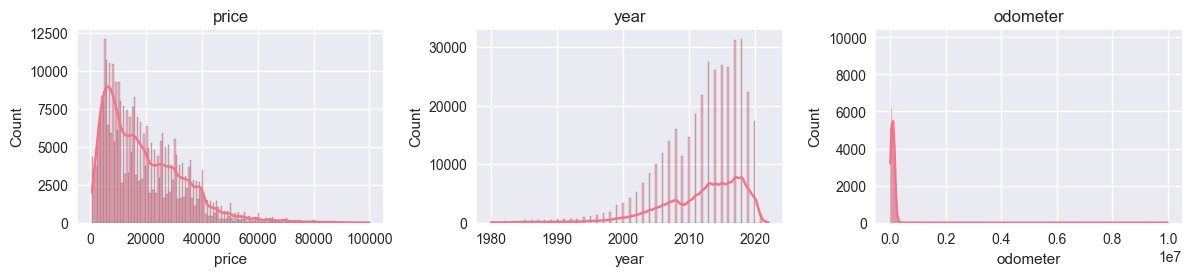

In [53]:
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns.tolist() 
print("\nDistribución de variables numéricas:")
chunk_size = 30
for j in range(0, len(numeric_cols), chunk_size):
    plt.figure(figsize=(20, 15))
    for i, col in enumerate(numeric_cols[j:j+chunk_size]):
        plt.subplot(6, 5, i+1)
        sns.histplot(dataset_clean[col], kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()

Visualizando estas distribuciones encontramos para la variable de los precios muestra que la mayoría de los autos se concentran entre $0 y $40,000 dólares, y los más caros llegan a costar hasta $100,000 de dólares. 
Para la distribución de los años vemos que es aprox. normal y centrada alrededor de 2010-2015. Hay pocos carros antiguos pues aumenta hacia años más recientes.
Y para el kilometraje se ve que la gran mayoría de los carros tiene menos de 200,000 km recorridos, pero se ve un valro extremo con más de 1,000,000 km de recorrido, por lo que hay presencia de atípicos

Por ello, vamos a revisar graficamente mediante boxplots las distribuciones de estos atípicos:

Número de columnas numéricas: 3
Columnas numéricas: ['price', 'year', 'odometer']


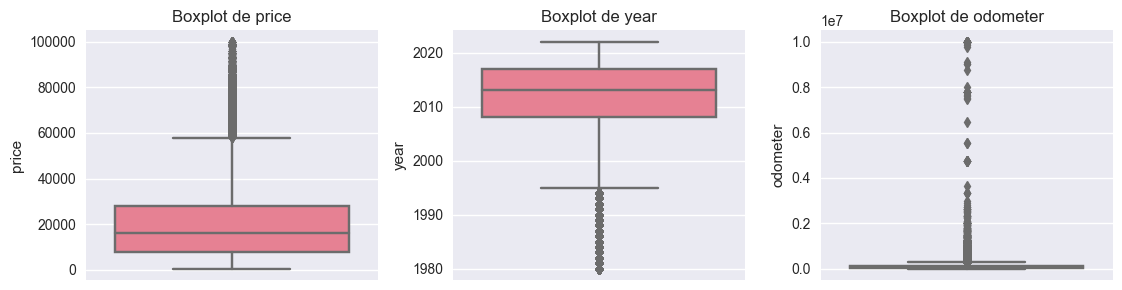

In [54]:
def plot_outliers(dataset_clean, columns):
    n_cols = len(columns)
    n_rows = (n_cols + 3) // 4  
    plt.figure(figsize=(15, 3 * n_rows))
    
    for i, col in enumerate(columns):
        plt.subplot(n_rows, 4, i+1)
        sns.boxplot(y=dataset_clean[col])
        plt.title(f'Boxplot de {col}')
    
    plt.tight_layout()
    plt.show()
numeric_cols = dataset_clean.select_dtypes(include=['int64', 'float64']).columns
print(f"Número de columnas numéricas: {len(numeric_cols)}")
print("Columnas numéricas:", list(numeric_cols))
plot_outliers(dataset_clean, numeric_cols)

Mediante la visualización de estos boxplots podemos ver, para la distribución de precios, los atípicos están por encima de $40,000 dólares, que representan carros que podrían ser de lujo. La mediana está alrededor de $15,000 a 20,000 dólares, es decir, la mitad de los carros vale menos que eso.
Para la variable año, la mitad de los carros salieron entre lo años 2008 a 2017 aprox. Los atípicos están por debajo del año 1995, siendo carro con más de 25 años. Y la mediana está alrededor de 2013, por lo que la mitad de los carros son de 2013 o más nuevos.
Y para el kilometraje la mayoría de los carros tiene menos de 200,000 km recorridos, pero con atípicos de más de 1,000,000+ km.

Por ello, empezamos analizar las correlaciones entre estas variables.

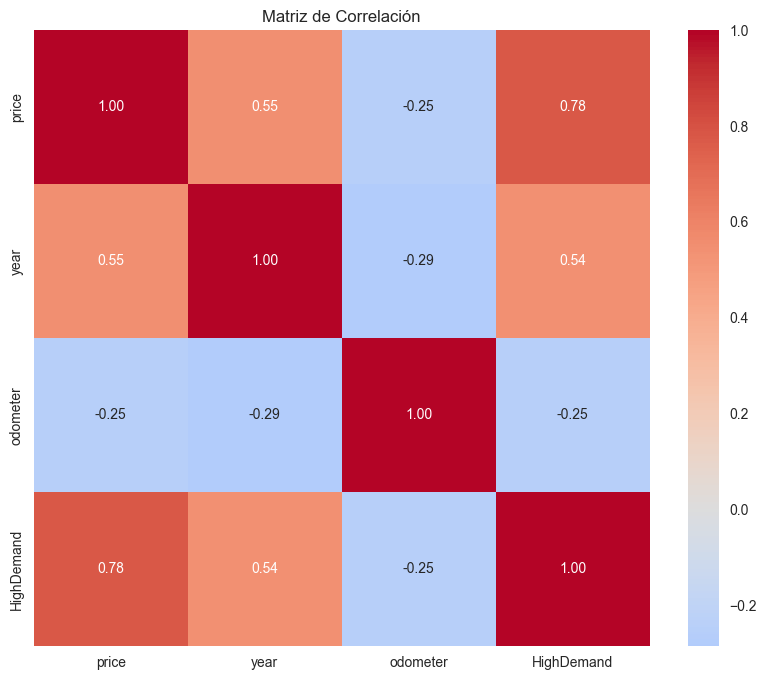

In [55]:
numeric_vars = ['price', 'year', 'odometer', 'HighDemand']
correlation_matrix = dataset_clean[numeric_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matriz de Correlación')
plt.show()


Analizamos que, para la relación entre año y precio hay correlación positiva, es decir, los carros más nuevos tienden a ser más caros. También entre kilometraje y el precio hay una correlación negativa, por lo que nos diría que los carros con más kilometraje tienden a ser más baratos pues al ser alto ese kilometraje significa más uso por el dueño pasado. Y los carros con más kilometraje tienden a tener menor demanda.

Entre la alta demanda y precio tienen una correlación positiva, es decir, los carros con alta demanda son más caros.

Entre los años y el kilometraje tienen una correlación negativa moderada pues los carros más nuevos tienden a tener menos kilometraje, y relacionandolo con la alta demanda, los carros más nuevos tienden a tener alta demanda.

Todas las variables tienen correlaciones moderadas entre los predictores.

Y para finalizar con el EDA, empezamos un análisis minucioso acerca de las relaciones y distribuciones de todas la variables. Primero, un análisis univariado:

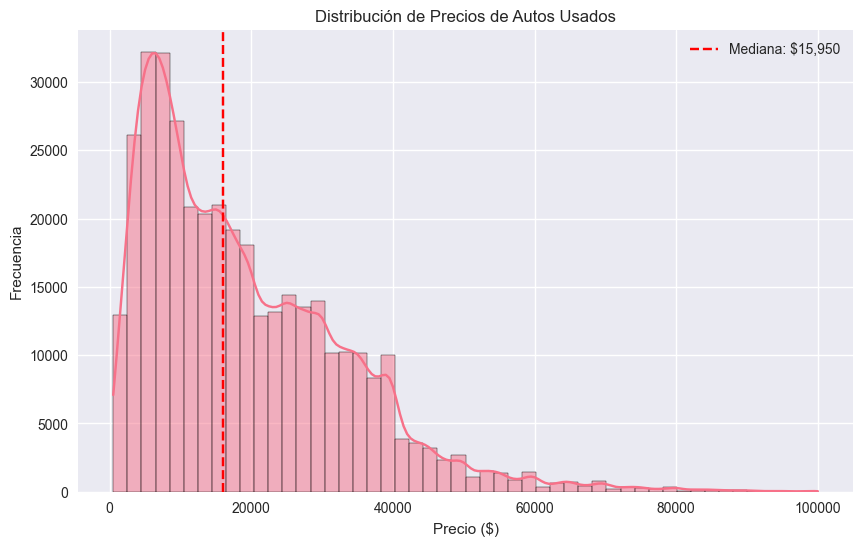

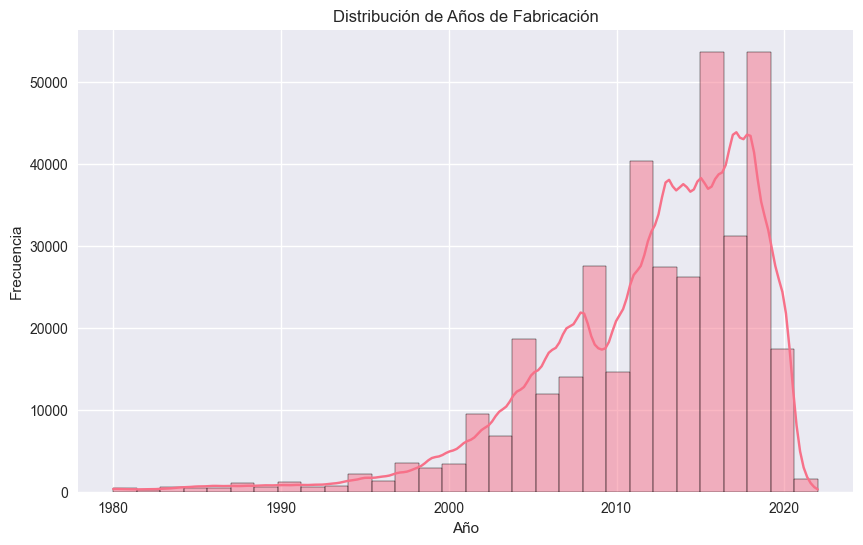

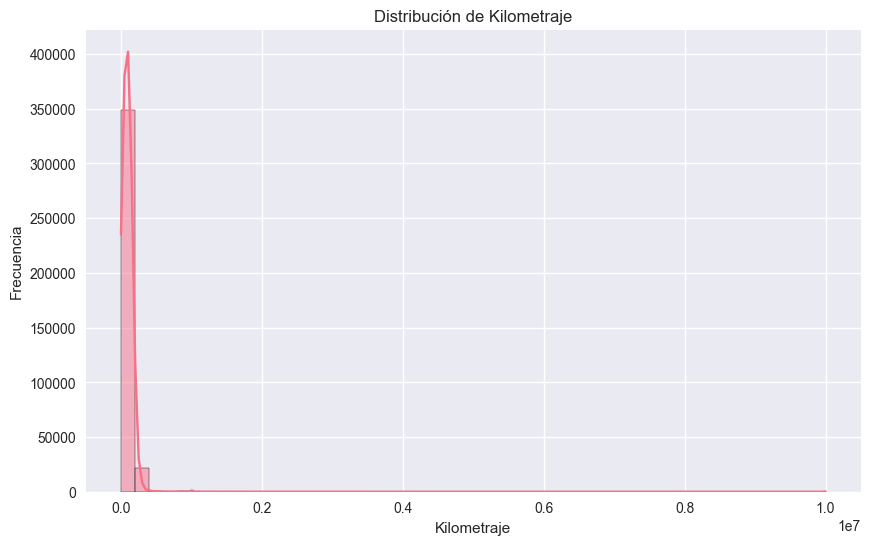

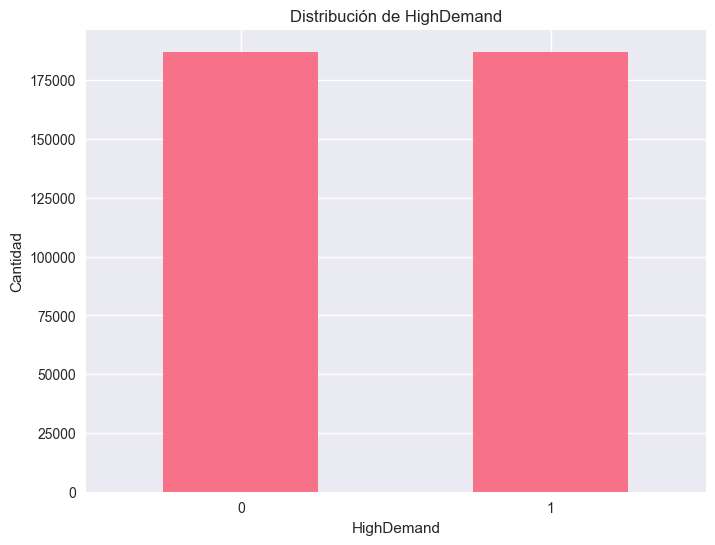

In [56]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl") 
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['price'], bins=50, kde=True)
plt.title('Distribución de Precios de Autos Usados')
plt.xlabel('Precio ($)')
plt.ylabel('Frecuencia')
plt.axvline(dataset_clean['price'].median(), color='red', linestyle='--', 
            label=f'Mediana: ${dataset_clean["price"].median():,.0f}')
plt.legend()
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['year'], bins=30, kde=True)
plt.title('Distribución de Años de Fabricación')
plt.xlabel('Año')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(10, 6))
sns.histplot(dataset_clean['odometer'], bins=50, kde=True)
plt.title('Distribución de Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Frecuencia')
plt.show()
plt.figure(figsize=(8, 6))
dataset_clean['HighDemand'].value_counts().plot(kind='bar')
plt.title('Distribución de HighDemand')
plt.xlabel('HighDemand')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

Para la primera gráfica observamos que la gran mayoría de los carros usados tienen precios por debajo de los $20,000 dólares, y la mitad de los carros se venden por menos de $15,950 dólares, es decir, son pocos los carros caros que se venden por su alto costo.

Para la segunda gráfica de distribución de años de fabricación vemos que hay muy pocos carros de las décadas de 1980 y 1990 en el dataset, pero aumentan a partir del año 2000, por lo que los carros usados que se venden son relativamente modernos. Pudiera decir que los carros más viejos ya se han chatarreado y son difíciles de vender. 

Para la tercera gráfica de distribución de kilometraje muestra que los carros usados tienden a venderse en rangos de kilometraje como de 30,000 a 40,000 km, 70,000 a 80,000 km, o 140,000 a 150,000 km. Esto se puede interpretar en la manera de que, si el carro esttá en período de garantía o un mantenimiento mayor, las personas tienden a vender el carro para más ganancias.

Y la última gráfica de distribución de HighDemand muestra que, aproximadamente entre el 60% y el 70% de los carros están etiquetados como de Alta Demanda, es decir, la mayoría se consideran populares, se podrían venden más rápido o tienen un precio más firme.

Luego de estos análisis, pasamos a uno bivariado:

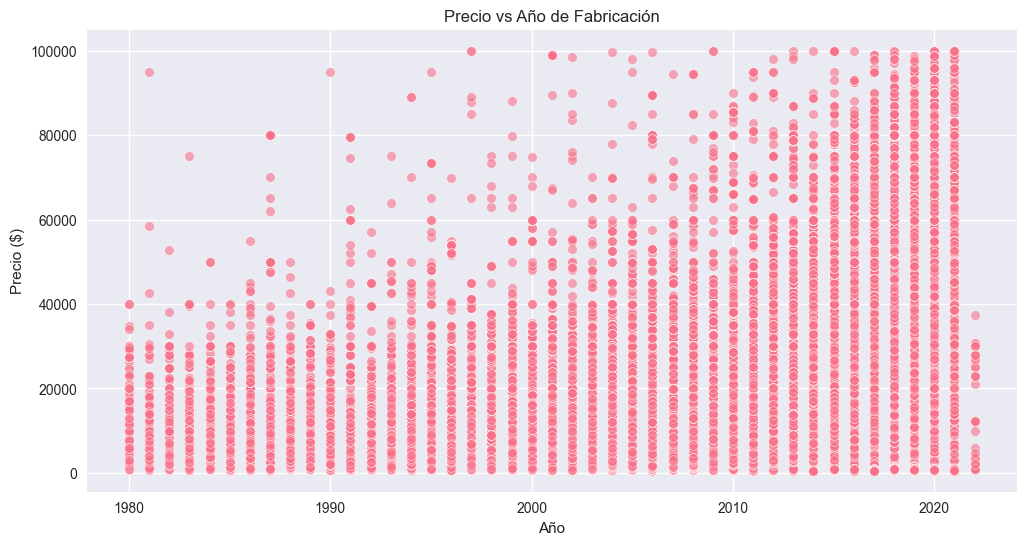

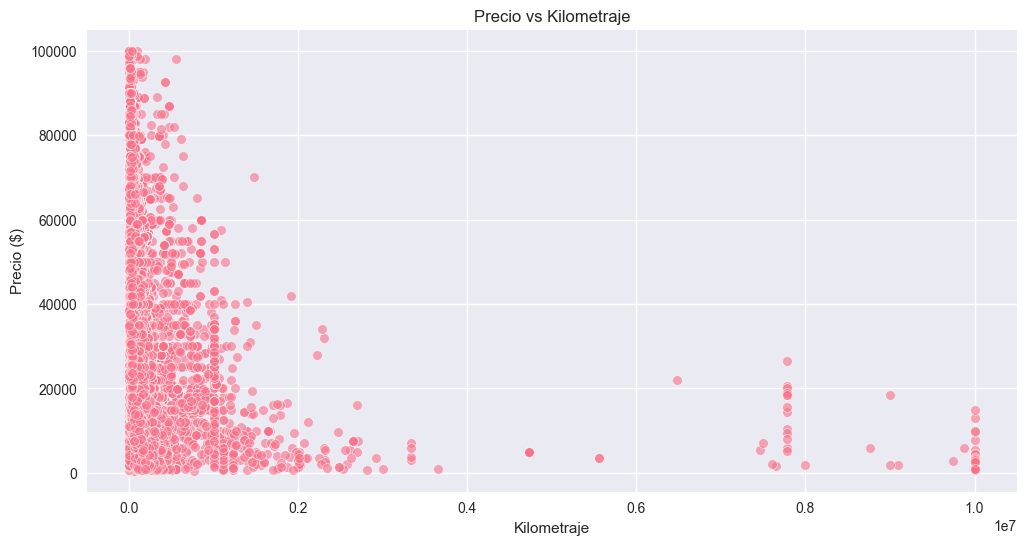

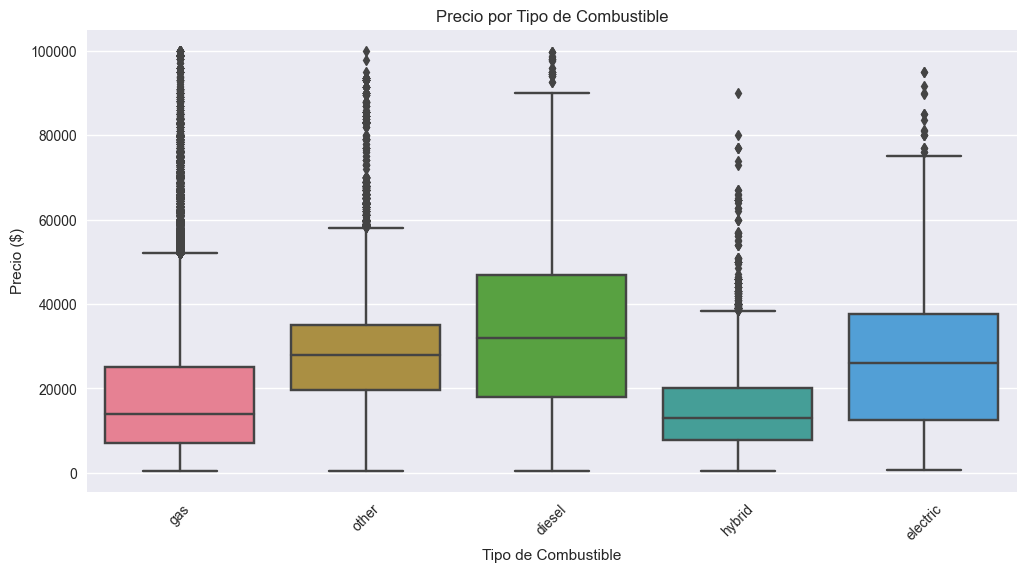

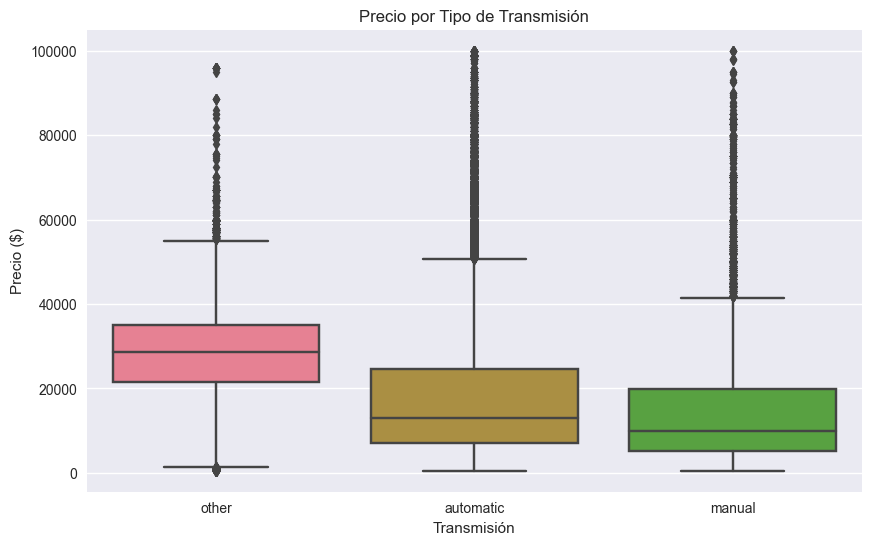

In [57]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='year', y='price', alpha=0.6)
plt.title('Precio vs Año de Fabricación')
plt.xlabel('Año')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=dataset_clean, x='odometer', y='price', alpha=0.6)
plt.title('Precio vs Kilometraje')
plt.xlabel('Kilometraje')
plt.ylabel('Precio ($)')
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(data=dataset_clean, x='fuel', y='price')
plt.title('Precio por Tipo de Combustible')
plt.xlabel('Tipo de Combustible')
plt.ylabel('Precio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=dataset_clean, x='transmission', y='price')
plt.title('Precio por Tipo de Transmisión')
plt.xlabel('Transmisión')
plt.ylabel('Precio ($)')
plt.show()

De acuerdo con lo visualizado, en el caso de la gráfica del precio con respecto al año de fabricación vemo que a medida que el año de fabricación es más reciente, el precio de venta aumenta pues los carros más nuevos valen significativamente más que los autos más viejos, con facotres como mejor tecnología, menos desgaste y más seguros para manejar. Y se tiene mucho en cuenta el año del modelo para determinar el precio del carro usado.

Para la relación de precio y kilometraje se muestra que un mayor kilometraje indicaría desgaste en el motor y otras partes del auto, lo que reduce su precio, por lo cual es clave para la valoración del carro usado.

Para la relación de precio por tipo de combustible muestra que los carros que usan el tipo de combustible 1, siendo los carros tipo eléctricos o híbrido", tienen un precio más alto que los carros que usan del tipo combustible 0, siendo la gasolina o diésel. Por ello, los vehículos como híbridos o eléctricos suelen tener un precio de venta alto, y en la gama de usado se refleja de igual manera

Para la relacion de precio por tipo de transmisión muestra que el tipo de transmisión, como las automáticas estándar añaden valor sobre las transmisiones manuales, con un precio casi similar, y las transmisiones avanzadas se encuentran en los carros más caros.

Análisis de tops

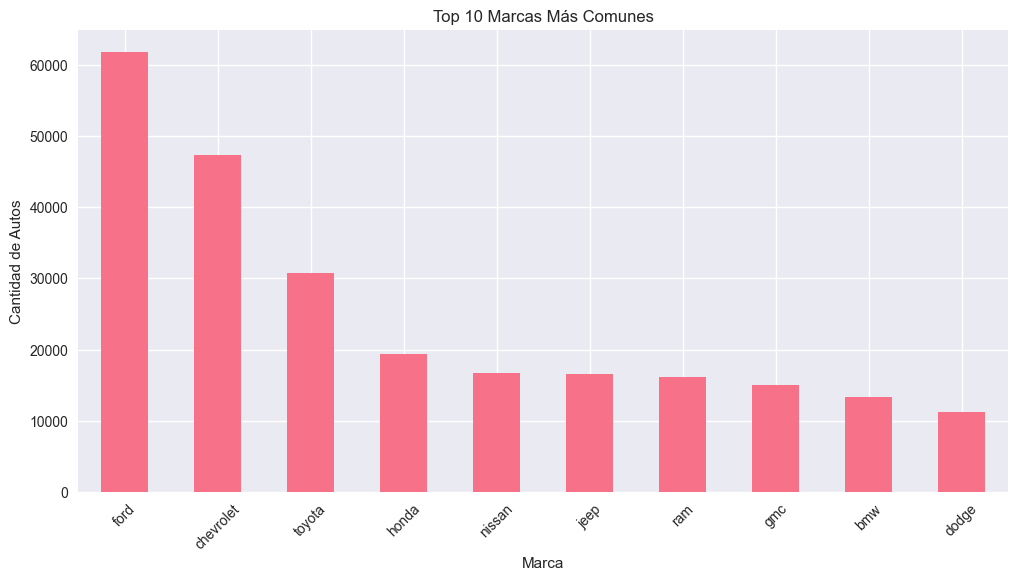

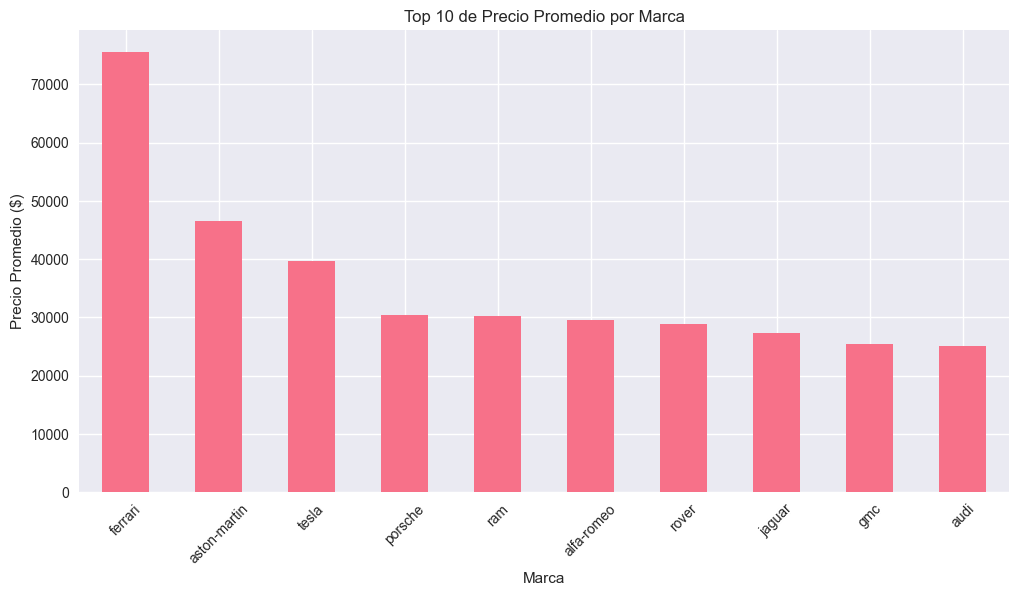

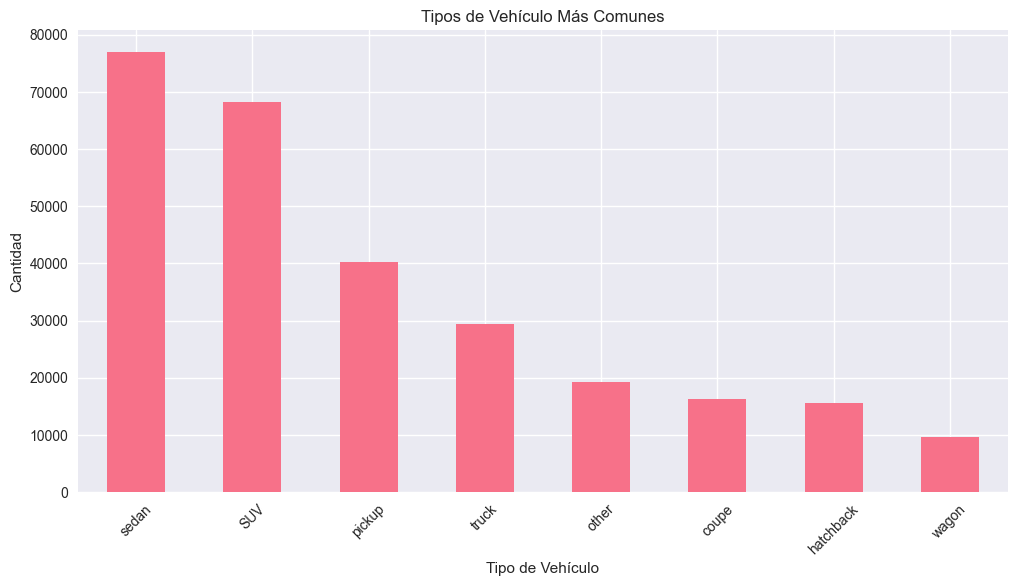

In [58]:
plt.figure(figsize=(12, 6))
top_10_brands = dataset_clean['manufacturer'].value_counts().head(10)
top_10_brands.plot(kind='bar')
plt.title('Top 10 Marcas Más Comunes')
plt.xlabel('Marca')
plt.ylabel('Cantidad de Autos')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
price_by_brand = dataset_clean.groupby('manufacturer')['price'].mean().sort_values(ascending=False).head(10)
price_by_brand.plot(kind='bar')
plt.title('Top 10 de Precio Promedio por Marca')
plt.xlabel('Marca')
plt.ylabel('Precio Promedio ($)')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))
dataset_clean['type'].value_counts().head(8).plot(kind='bar')
plt.title('Tipos de Vehículo Más Comunes')
plt.xlabel('Tipo de Vehículo')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

Para el gráfico del top 10 aarcas más comunes muestra que marcas como diametal, bydia, honda, riesan y jeep dominan en el mercado de carros, siendo las marcas más populares. 
Se puede inferir solo con esa visualización que esa la alta venta de estos carros, por lo que son los más acaparados y terminan en estas compra/venta de carros. También puede ser el gran consumo de las personas por estas marcas por su mayor oferta en precio o las varias opciones de estos tipos de carros, como el color, tipo de modelo como deportivos o casuales.

Para el gráfico de top 10 de precio promedio por marca se muestra un prestigio hacia ellas pues en el mercado son las más lujosas o con exclusividad hacia el cliente, como ferrari, porsche, land rover, y jaguar. Algo interesante es que las marcas más comunes del gráfico 1 no aparecen en este top 10 de precios altos, por lo que se nota una grán diferencia entre el precio y la exclusividad, siendo los carros más comunes en el mercado sean más vendidos. Así, las marcas de lujo tienen menos cantidad en el mercado y se venden en precios más altos.

Y para la gráfica de tipos de vehículo más comunes muestra la demanda por los tipos específicos de carrocería para carros como sedanes, SUVs y pickups son los tipos de vehículo más populares. Comparandolo con los demás gráficos vemos que ños SUVs y pickups son populares por ser más variados en cantidad y estilo, y los sedanes son más comunes por tener más volumen o cantidad en el mercado. 

Analizando estas 3 gráficas podemos concluir una estrategia que pudieran estar usando los vendedores es, como el mercado está dominado por marcas comunes o de costo medio como Honda, Nissan o Jeep dán un aspecto de ser más accesibles para todos, con más opciones de estilos y un mejor costo-beneficio para el comprador. Y para marcas de lujo como Ferrari, Porsche o Jaguar ofrece un estatus de lujo y poder venderlos más caros.

Teniendo en cuenta todos los comportamientos de nuestras variables gracias al EDA podemos iniciar con construción, entrenamiento y evaluación de nuestros modelos:

In [59]:
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'model', 'fuel', 'transmission', 
                       'title_status', 'type', 'drive', 'paint_color', 'region', 'state']
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


X = dataset_clean[numeric_features + categorical_features]
y_reg = dataset_clean['price']
y_clf = dataset_clean['HighDemand']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

# Ridge
ridge_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Lasso
lasso_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=10000, random_state=42))
])

# Logistic Regression
logreg_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression())
])

Iniciamos con Ridge:

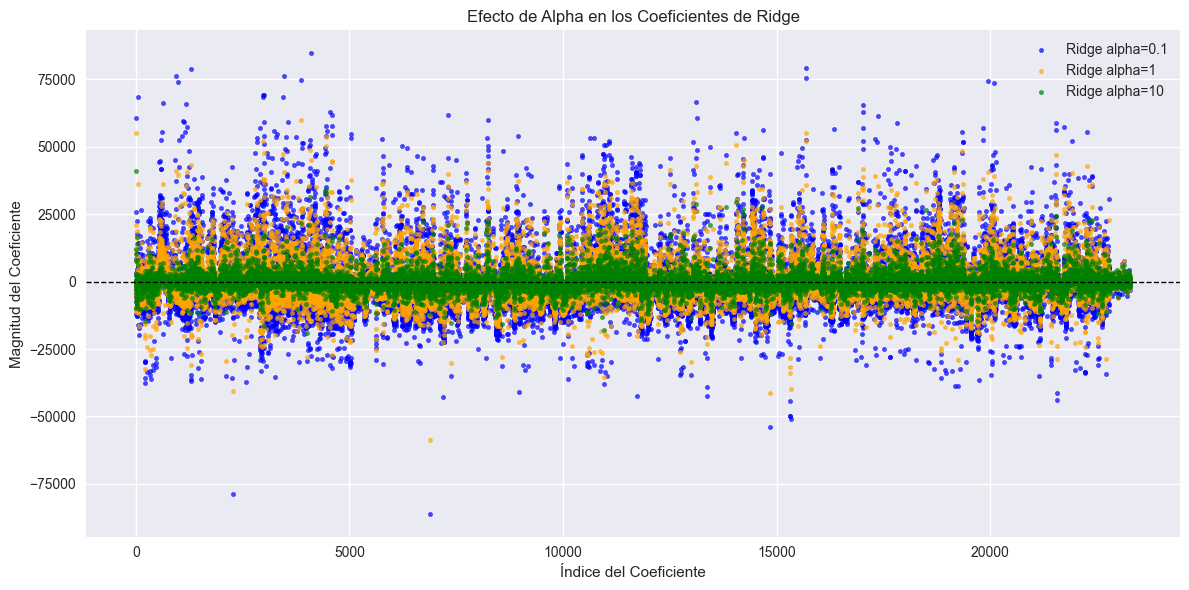

In [60]:
alphas = [0.1, 1, 10]
coef_dict = {}

for alpha in alphas:
    ridge = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=alpha))
    ])
    ridge.fit(X_reg_train, y_reg_train)
    coef_dict[alpha] = ridge.named_steps['model'].coef_

plt.figure(figsize=(12,6))
colors = {0.1: "blue", 1: "orange", 10: "green"}
for alpha, coefs in coef_dict.items():
    plt.scatter(range(len(coefs)), coefs, 
                s=10, alpha=0.7, 
                color=colors[alpha], 
                label=f'Ridge alpha={alpha}')

plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel("Índice del Coeficiente")
plt.ylabel("Magnitud del Coeficiente")
plt.title("Efecto de Alpha en los Coeficientes de Ridge")
plt.legend()
plt.tight_layout()
plt.show()

Notamos que evaluamos los respectivos alphas, 0.1, 1 y 10.

Vemos que en caso de 10 se realiza una regularizacion fuerte, lo que hace que el modelo se simplifique mucho, esto puede hacer que haya underfitting.

Ahora con el Alpha 1 vemos que hay una regularizacion moderada, haciendo que el modelo sea mas estable y generalizable, al usar 1 suele ser el punto de equilibro entre los 3 alphas que usamos. Y con Alpha 0.1 hay una regularizacion debil, aproximandose mas a una regresion lineal normal, con este alpha corremos el riesgo de sobreajustar los datos.

In [61]:
ridge_params = {'model__alpha': [0.1, 1, 10]}
ridge_grid = GridSearchCV(ridge_pipe, ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_reg_train, y_reg_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['year',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'model',
                                                                          'fuel',
                                                                          'transmission',
                                                                          'title_status',
                                                                          'type',
                                                                          'drive',
                                                                          'paint_color',
                                                                          'region',
                                                                          'state'])])),
                                       ('model', Ridge())]),
             param_grid={'model__alpha': [0.1, 1, 10]}, scoring='r2')

In [62]:
print("Mejor Ridge alpha:", ridge_grid.best_params_)

Mejor Ridge alpha: {'model__alpha': 0.1}


Luego de aplicar GridSearch, el cual hace es probar varias combinaciones de parametros, en este caso alphas, para cada combinacion y entrena el modelo y evalua su desempeño utilizando validacion cruzada, notamos que el mejor Alpha que nos ofrecio fue el de 0.1.

In [63]:
y_pred_ridge = ridge_grid.predict(X_reg_test)

In [64]:
print("\nRidge:")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_ridge))
print("RMSE", np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge)))
print("R²:", r2_score(y_reg_test, y_pred_ridge))


Ridge:
MAE: 4080.823126423401
RMSE 6740.107771208383
R²: 0.7739903528998795


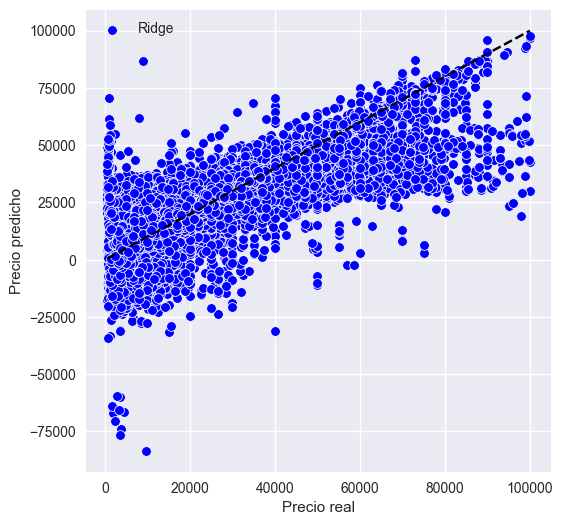

In [65]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_reg_test, y=y_pred_ridge, label="Ridge", color="blue")
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         'k--')
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.legend()
plt.show()

Mediante está gráfica muestra un desempeño notablemente en la predicción de precios de carros usados pues hay una clara tendencia lineal donde la mayoría de los puntos se agrupan en la línea diagonal, lo que pudiera decir la relación entre las características de los vehículos y sus precios de mercado. Se detecta una mayor dispersión en el rango de precios superiores a $60,000 dólares, por lo que el modelo podría tener problemas al predecir con precisión el el precio de los carros de gama alta.

Eso lo justifcia con el R² de 0.774, lo que dice que hay un 77.4% de la variabilidad en los precios, mientras que el error absoluto medio de $4,081 muestra que las predicciones se desvían por esta cantidad respecto al precio real, como del auto nuevo. Esta precisión pueden ser de gran ayuda para los vendedores para clasificar lo que requiere la demanda si se hace digitalmente pues se pueden poner más opciones para el cliente de lo que éste quisiera en un carro usado.

Por ello, el modelo Ridge demuestra ser efectivo para la predicción de precios de carros usados, con un desempeño en el rango de precios medios y para la mejora en carros con valor alto.

Ahora, juntamos esto con la regresión logarítmica:

In [66]:
logreg_params = {'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]}

logreg_grid = GridSearchCV(logreg_pipe, logreg_params, cv=5, scoring='accuracy')
logreg_grid.fit(X_clf_train, y_clf_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['year',
                                                                          'odometer']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['manufacturer',
                                                                          'model',
                                                                          'fuel',
                                                                          'transmission',
                                                                          'title_status',
                                                                          'type',
                                                                          'drive',
                                                                          'paint_color',
                                                                          'region',
                                                                          'state'])])),
                                       ('model', LogisticRegression())]),
             param_grid={'model__C': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100,
                                      1000]},
             scoring='accuracy')

In [67]:
print(logreg_grid.best_params_)

{'model__C': 10}


In [68]:
y_pred = logreg_grid.best_estimator_.predict(X_clf_test)
y_proba = logreg_grid.best_estimator_.predict_proba(X_clf_test)[:, 1]  # probas clase positiva
print("Métricas en el conjunto de prueba:")
print("Accuracy:", accuracy_score(y_clf_test, y_pred))
print("Precision:", precision_score(y_clf_test, y_pred))
print("Recall:", recall_score(y_clf_test, y_pred))
print("F1-score:", f1_score(y_clf_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_clf_test, y_proba))

print("\nReporte completo:")
print(classification_report(y_clf_test, y_pred))

Métricas en el conjunto de prueba:
Accuracy: 0.9156494418076074
Precision: 0.9163494021127139
Recall: 0.9146573179543448
F1-score: 0.9155025781825487
AUC-ROC: 0.9670239522928956

Reporte completo:
              precision    recall  f1-score   support

           0       0.91      0.92      0.92     37428
           1       0.92      0.91      0.92     37367

    accuracy                           0.92     74795
   macro avg       0.92      0.92      0.92     74795
weighted avg       0.92      0.92      0.92     74795



Vemos que, con un accuracy del 91.56%, el modelo clasifica más de 9 de cada 10 carros, lo que representa un nivel de precisión para administrar los precios dado que la precisión del 91.63% predice que un carrro tiene alta demanda, con el 91% de los casos esta predicción es correcta, por lo que podría minimizar los falsos positivos. Y el recall del 91.47% muestra que el modelo identifica la gran mayoría de los carros que realmente presentan alta demanda.

El F1-score del 91.55% confirma que el modelo no presenta sesgos hacia alguna clase específica de carro, sean carros de alta o baja demanda, así como el valor AUC-ROC de 96.70% también puede distinguir entre carros de alta y baja demanda.


Con esto información, podemos modelar y comparara con Lasso:

In [69]:
high_cardinality_features = ['model', 'manufacturer', 'region', 'paint_color']
for feature in high_cardinality_features:
    if feature in X_reg_train.columns:
        top_categories = X_reg_train[feature].value_counts().head(15).index
        X_reg_train[feature] = X_reg_train[feature].where(
            X_reg_train[feature].isin(top_categories), 'other'
        )
        X_reg_test[feature] = X_reg_test[feature].where(
            X_reg_test[feature].isin(top_categories), 'other'
        )
        X_clf_train[feature] = X_clf_train[feature].where(
            X_clf_train[feature].isin(top_categories), 'other'
        )
        X_clf_test[feature] = X_clf_test[feature].where(
            X_clf_test[feature].isin(top_categories), 'other'
        )
print("Columnas en X_reg_train:", list(X_reg_train.columns))
print("Columnas en X_reg_test:", list(X_reg_test.columns))
numeric_features = ['year', 'odometer']
categorical_features = ['manufacturer', 'model', 'fuel', 'transmission',
                       'title_status', 'type', 'drive', 'paint_color', 'region', 'state']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
lasso_pipe_fast = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42))
])

lasso_params_optimized = {
    'model__alpha': [0.1, 1],
    'model__max_iter': [500],
    'model__tol': [0.1],
    'model__selection': ['cyclic']
}

lasso_grid_optimized = GridSearchCV(
    lasso_pipe_fast, 
    lasso_params_optimized, 
    cv=2,
    scoring='r2',
    n_jobs=1,
    verbose=1
)
sample_size = int(0.2 * len(X_reg_train))
train_indices = np.random.choice(len(X_reg_train), sample_size, replace=False)

X_reg_train_fast = X_reg_train.iloc[train_indices]
y_reg_train_fast = y_reg_train.iloc[train_indices]
lasso_grid_optimized.fit(X_reg_train_fast, y_reg_train_fast)

print("Mejores parámetros para Lasso:", lasso_grid_optimized.best_params_)
y_pred_lasso = lasso_grid_optimized.predict(X_reg_test)

print("Resultados Lasso:")
print("MAE:", mean_absolute_error(y_reg_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso)))
print("R²:", r2_score(y_reg_test, y_pred_lasso))

print(f"Comparado con Ridge:")
print(f"Ridge R²: {r2_score(y_reg_test, y_pred_ridge):.4f}")
print(f"Lasso R²: {r2_score(y_reg_test, y_pred_lasso):.4f}")

if r2_score(y_reg_test, y_pred_lasso) > r2_score(y_reg_test, y_pred_ridge):
    print("Lasso supera a Ridge")
else:
    print("Ridge supera a Lasso")

Columnas en X_reg_train: ['year', 'odometer', 'manufacturer', 'model', 'fuel', 'transmission', 'title_status', 'type', 'drive', 'paint_color', 'region', 'state']
Columnas en X_reg_test: ['year', 'odometer', 'manufacturer', 'model', 'fuel', 'transmission', 'title_status', 'type', 'drive', 'paint_color', 'region', 'state']
Fitting 2 folds for each of 2 candidates, totalling 4 fits
Mejores parámetros para Lasso: {'model__alpha': 1, 'model__max_iter': 500, 'model__selection': 'cyclic', 'model__tol': 0.1}
Resultados Lasso:
MAE: 6492.383905754333
RMSE: 9356.826261389162
R²: 0.5644375553286334
Comparado con Ridge:
Ridge R²: 0.7740
Lasso R²: 0.5644
Ridge supera a Lasso


Para esta evaluación entre Ridge y Lasso tuvimos que hacer unas modificaciones pues el problema era en que el pipeline de preprocesamiento, se había sido definido antes de realizar la reducción de categorías en variables de alta cardinalidad. 

Por ello, se demoraba un tiempo excpecionalmente alto y no se podía continuar con el estudio, entonces se aplicó la reducción de categorías a las variables de alta cardinalidad como 'model', 'manufacturer', 'region' y 'paint_color', conservando solo las 15 categorías más frecuentes y agrupando el resto bajo la etiqueta 'other'. Y se redefinió el pipeline de preprocesamiento utilizando las columnas actualizadas, así el ColumnTransformer estuviera alineado con la estructura de datos ya modificada. 

También configuró el GridSearchCV con parámetros específicos para acelerar el proceso, incluyendo menos folds de validación cruzada, menos iteraciones y una tolerancia más baja, así se leía solo el 20% de los datos de entrenamiento para reducir el tiempo de ejcución de la celda para después compararlo con el modelo Ridge y así interpretarlos.


Mediantes estos resultados se destaca la diferencia en el desempeño entre los modelos Ridge y Lasso para la predicción de los precios de estos carros. El modelo Ridge muestra un rendimiento superior con un R² de 0.7740, es decir, un 77.4% de la variabilidad en los precios. Mientras que el modelo Lasso muestra un desempeño bajo con un R² de 0.5614, o sea, un 56.1% de la variación en los precios.

Entre estos dos modelos que tienen una diferencia de más de 20 puntos con una superioridad de Ridge sugiere que, para este conjunto de datos específico, la regularización L2 es más efectiva que la selección de variables mediante L1 que realiza Lasso. Esto podría deberse a que múltiples variables contribuyen de manera moderada al precio.

En conclusión, el modelo Ridge emerge claramente como la opción superior para esta aplicación específica, ofreciendo predicciones más precisas para la estimación de precios de carros usados.

Ahora, para analizar fondo la clasificación, haremos una matriz de confusión de la alta demanda:

(array([0.5, 1.5]),
 [Text(0, 0.5, 'Baja Demanda'), Text(0, 1.5, 'Alta Demanda')])

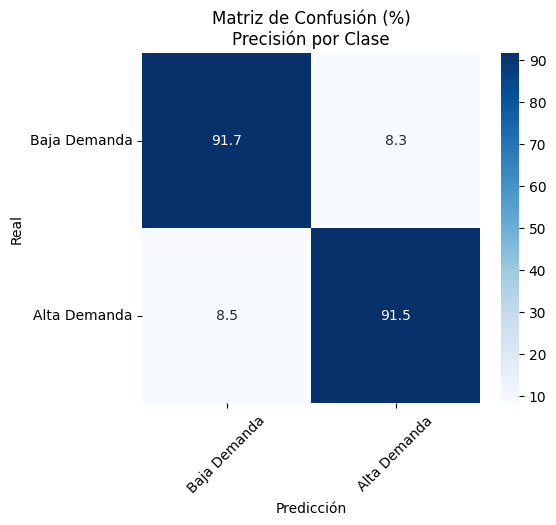

In [70]:
plt.style.use('default')
sns.set_palette("Set2")
plt.figure(figsize=(12, 10))
plt.subplot(2, 2, 1)
cm = confusion_matrix(y_clf_test, y_pred)
cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_percentage, annot=True, fmt='.1f', cmap='Blues', 
            xticklabels=['Baja Demanda', 'Alta Demanda'],
            yticklabels=['Baja Demanda', 'Alta Demanda'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión (%)\nPrecisión por Clase')
plt.xticks(rotation=45)
plt.yticks(rotation=0)



En la matriz de confusión se evidencia un desempeño alto del modelo de clasificación para predecir pues los resultados muestran qque, para alcanzar una precisión del 91.7%, se deben identficar correctamente los carros baja demanda, mientras que logra un 91.5% de acierto en la detección de carros con alta demanda. 
Esta mínima entre ambas clases muestra un equilibrio casi perfecto, por lo que  el modelo no presenta sesgos hacia ninguna categoría.

También los errores del modelo son bajos con solo un 8.3% de falsos positivos, siendo carros clasificados erróneamente como con alta demanda, y un 8.5% de falsos negativos, siendo carros de alta demanda que no son identificados correctamente. 

La consistencia en los porcentajes de acierto y error en ambas clases dice que el modelo aprendió patrones robustos y generalizables, dando así la identificación de oportunidades y negar malas inversiones para esta compra/venta de carros usados.

Curva ROC con Regresión

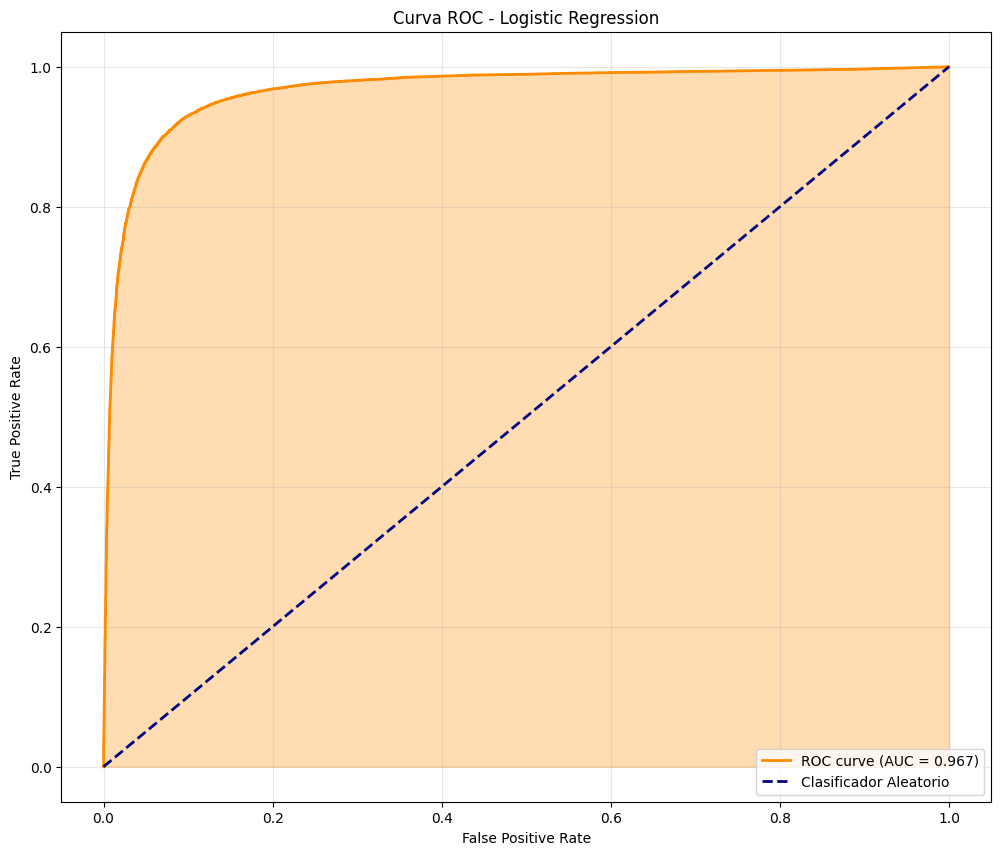

In [71]:
plt.figure(figsize=(12, 10))
fpr, tpr, thresholds = roc_curve(y_clf_test, y_proba)
roc_auc = roc_auc_score(y_clf_test, y_proba)

plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio')
plt.fill_between(fpr, tpr, alpha=0.3, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

Curva ROC Precision-Recall
Evidenciamos que la curva se eleva rápidamente hacia izquierda del gráfico y arriba, mostrando que el modelo alcanza una alta tasa de verdaderos positivos mientras mantiene una baja tasa de falsos positivos y puede identificar correctamente la mayoría de los carros con alta demanda antes de comenzar a cometer errores significativos de clasificación.

La distancia entre la curva del modelo y la línea diagonal del clasificador, con un AUC de 0.5, confirma que el modelo tiene poder predictivo, y el AUC de 0.967 significa que existe un 96.7% de probabilidad de que el modelo clasifique correctamente un par aleatorio de autos si uno tiene alta demanda y el otro baja demanda.

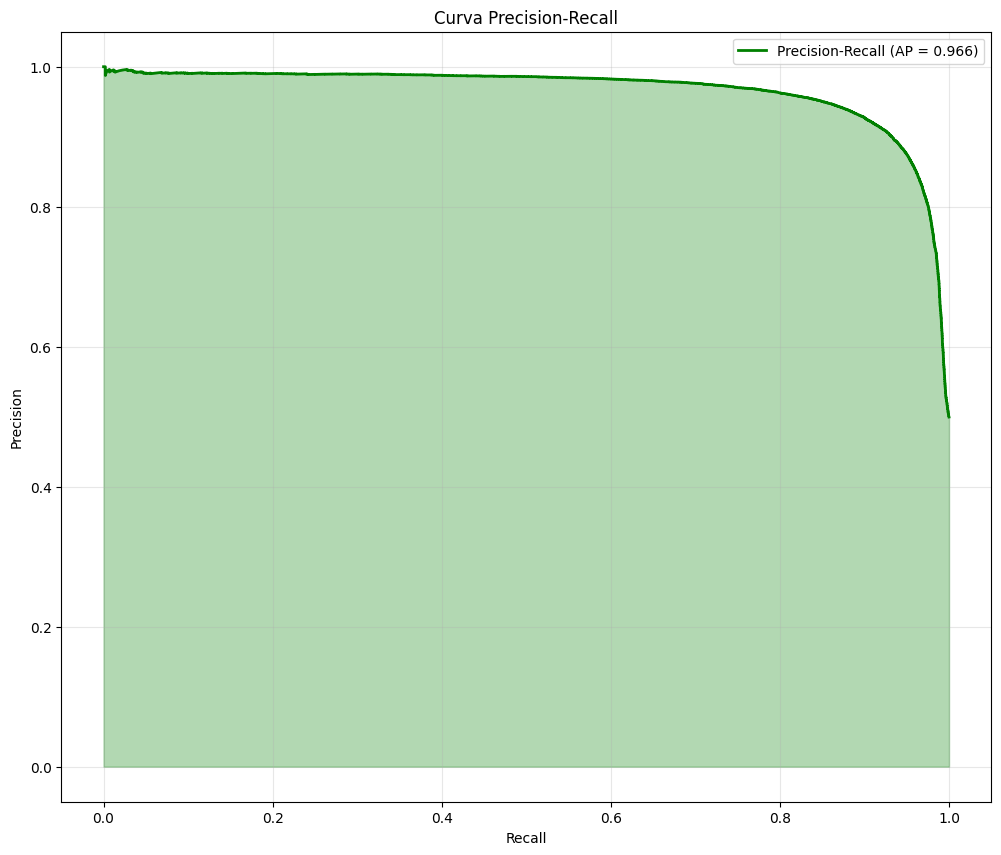

In [72]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(12, 10))
precision, recall, _ = precision_recall_curve(y_clf_test, y_proba)
avg_precision = average_precision_score(y_clf_test, y_proba)

plt.plot(recall, precision, color='green', lw=2, label=f'Precision-Recall (AP = {avg_precision:.3f})')
plt.fill_between(recall, precision, alpha=0.3, color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

La curva muestra un desempeño alto en el modelo de clasificación, con un AP de 0.966, lo que significa que significa que el modelo tiene un 96.6% de la capacidad para identificar carros de alta demanda y una efectividad en la capacidad para clasificar correctamente carros de alta demanda en todos los posibles umbrales de decisión.

La curva mantiene niveles de precisión cercanos al 90% o más en todo el rango de recall, lo que indica que el modelo puede identificar correctamente la gran mayoría de los carros con alta demanda mientras mantiene una tasa de error muy baja. 

Por ello, verificamos los umbrales óptimos

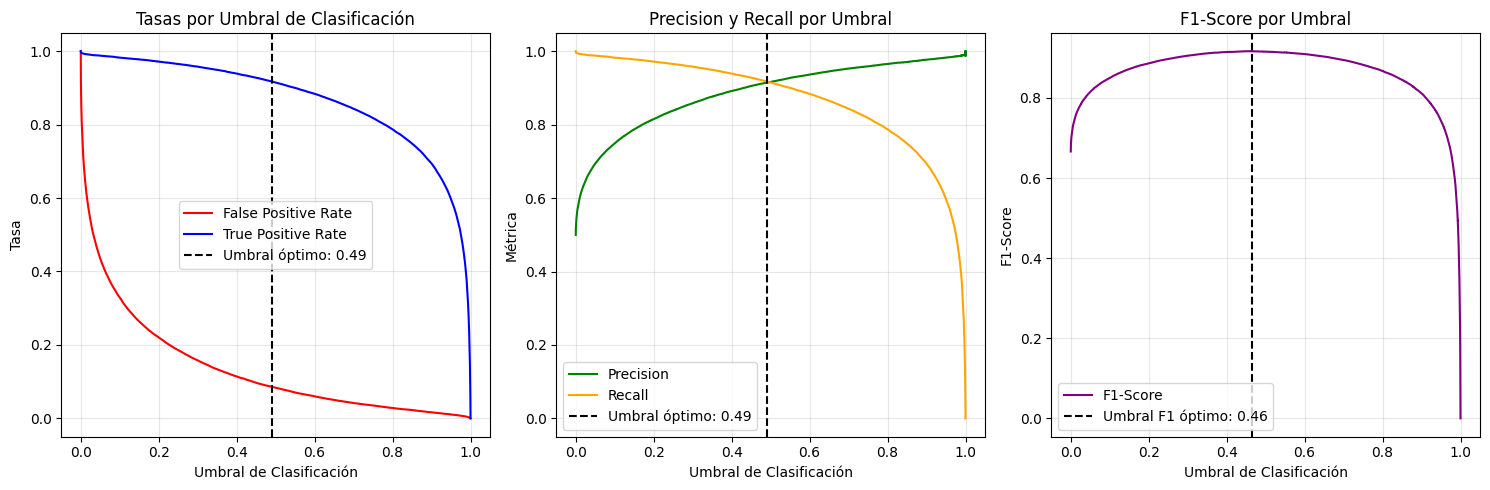

In [73]:
plt.figure(figsize=(15, 5))
distances = np.sqrt(fpr**2 + (1-tpr)**2)
optimal_idx = np.argmin(distances)
optimal_threshold = thresholds[optimal_idx]

plt.subplot(1, 3, 1)
plt.plot(thresholds, fpr, label='False Positive Rate', color='red')
plt.plot(thresholds, tpr, label='True Positive Rate', color='blue')
plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Umbral óptimo: {optimal_threshold:.2f}')
plt.xlabel('Umbral de Clasificación')
plt.ylabel('Tasa')
plt.title('Tasas por Umbral de Clasificación')
plt.legend()
plt.grid(True, alpha=0.3)

# Comparación por umbral
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds_pr = precision_recall_curve(y_clf_test, y_proba)

plt.subplot(1, 3, 2)
plt.plot(thresholds_pr, precisions[:-1], label='Precision', color='green')
plt.plot(thresholds_pr, recalls[:-1], label='Recall', color='orange')
plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Umbral óptimo: {optimal_threshold:.2f}')
plt.xlabel('Umbral de Clasificación')
plt.ylabel('Métrica')
plt.title('Precision y Recall por Umbral')
plt.legend()
plt.grid(True, alpha=0.3)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

plt.subplot(1, 3, 3)
plt.plot(thresholds_pr, f1_scores[:-1], label='F1-Score', color='purple')
optimal_f1_idx = np.argmax(f1_scores[:-1])
optimal_f1_threshold = thresholds_pr[optimal_f1_idx]
plt.axvline(optimal_f1_threshold, color='black', linestyle='--', label=f'Umbral F1 óptimo: {optimal_f1_threshold:.2f}')
plt.xlabel('Umbral de Clasificación')
plt.ylabel('F1-Score')
plt.title('F1-Score por Umbral')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

El primer gráfico muestra que el umbral óptimo de 0.49 tiene un punto de equilibrio casi perfecto entre los verdaderos positivos y falsos positivos. Este valor cercano a 0.5 confirma que el modelo está calibrado y no presenta sesgos hacia ninguna clase. Y la cercania de las dos curvas muestra que el modelo mantiene un balance consistente en los umbrales

En la segunda grafica de precisión y recall tienen el mismo umbral de 0.49 mostrando un equilibrio entre estas dos métricas. Ambas curvas altas indica que el modelo puede minimizar falsos positivos mientras alcanza un alto recall, es decir, la mayoría de los verdaderos positivos.

Y el tercer gráfico de F1-Score alcanza su punto alrededor del mismo umbral, dando así que el punto 0.49 es el punto óptimo para maximizar el balance entre precisión y recall y así el modelo es robusto a variaciones en el umbral de clasificación.

Análisis de errores con clasificación:
Total de errores: 6309 de 74795 (8.4%)
Falsos Positivos: 3120 (4.2%)
Falsos Negativos: 3189 (4.3%)
Métricas por clase
Métricas por clase:
              precision  recall  f1-score     support
Baja Demanda     0.9150  0.9166    0.9158  37428.0000
Alta Demanda     0.9163  0.9147    0.9155  37367.0000
accuracy         0.9156  0.9156    0.9156      0.9156
macro avg        0.9157  0.9156    0.9156  74795.0000
weighted avg     0.9157  0.9156    0.9156  74795.0000


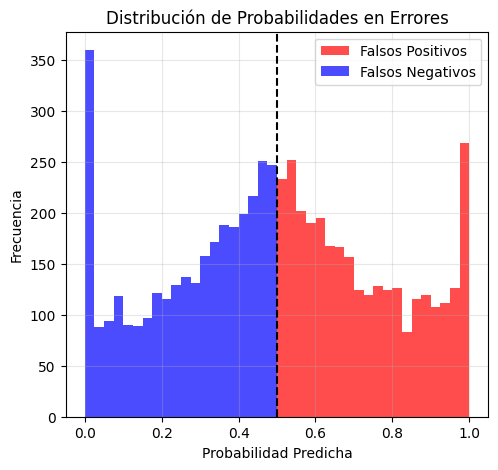

In [74]:
results_df = X_clf_test.copy()
results_df['HighDemand_Real'] = y_clf_test.values
results_df['HighDemand_Pred'] = y_pred
results_df['Probabilidad'] = y_proba
results_df['Error'] = results_df['HighDemand_Real'] != results_df['HighDemand_Pred']

print("Análisis de errores con clasificación:")
print(f"Total de errores: {results_df['Error'].sum()} de {len(results_df)} ({results_df['Error'].mean()*100:.1f}%)")
false_positives = ((results_df['HighDemand_Real'] == 0) & (results_df['HighDemand_Pred'] == 1)).sum()
false_negatives = ((results_df['HighDemand_Real'] == 1) & (results_df['HighDemand_Pred'] == 0)).sum()

print(f"Falsos Positivos: {false_positives} ({false_positives/len(results_df)*100:.1f}%)")
print(f"Falsos Negativos: {false_negatives} ({false_negatives/len(results_df)*100:.1f}%)")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
fp_proba = results_df[(results_df['HighDemand_Real'] == 0) & (results_df['HighDemand_Pred'] == 1)]['Probabilidad'] 
fn_proba = results_df[(results_df['HighDemand_Real'] == 1) & (results_df['HighDemand_Pred'] == 0)]['Probabilidad']

plt.hist(fp_proba, bins=20, alpha=0.7, label='Falsos Positivos', color='red')
plt.hist(fn_proba, bins=20, alpha=0.7, label='Falsos Negativos', color='blue')
plt.axvline(0.5, color='black', linestyle='--')
plt.xlabel('Probabilidad Predicha')
plt.ylabel('Frecuencia')
plt.title('Distribución de Probabilidades en Errores')
plt.legend()
plt.grid(True, alpha=0.3)

print("Métricas por clase")
report = classification_report(y_clf_test, y_pred, target_names=['Baja Demanda', 'Alta Demanda'], output_dict=True)
report_df = pd.DataFrame(report).transpose().round(4)
print("Métricas por clase:")
print(report_df)

El modelo muestra solo 8.4% de errores en total, distribuidos así:

- 4.2% Falsos Positivos: unos 3120 carros son clasificados como alta demanda pero realmente son baja demanda.

- 4.3% Falsos Negativos: unos 3189 carros son lasificados como baja demanda pero realmente son alta demanda.

Así, el modelo no tiene sesgos hacia ningún tipo de error entre ambos tipos de clasificación incorrecta.

En las métricas tenemos que: 

- Baja Demanda:

    Precisión: 91.50% son correctos.

    Recall: detecta un 91.66% de todos los carros con baja demanda real.

    F1-Score: 91.58% hay un balance entre precisión y recall.

- Alta Demanda:

    Precisión: 91.63% son correctos.

    Recall: detecta 91.47% de todos los carros con alta demanda real.

    F1-Score: 91.55% hay un balance similar al de baja demanda.


La gráfica muestra que los falsos positivos se concentran alrededor de probabilidades entre 0.5 a 0.7, y los falsos negativos se concentran alrededor de probabilidades entre 0.3 a 0.5, es decir, la zona de incertidumbre al umbral de 0.5 da donde el modelo tiene menos confianza en sus predicciones y pocos errores, lo que muestra que cuando el modelo está seguro y casi siempre acierta.

Por ello, para el estudio muestra que solo el 4.2% tiene riesgo de recomendar carros poco demandados y un 4.3% con oportunidades perdidas de carros muy demandados.

In [75]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                            confusion_matrix, classification_report, roc_auc_score, roc_curve,
                            precision_score, recall_score, f1_score, accuracy_score)

print("Ridge vs Lasso")
regression_results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso'],
    'MAE': [
        mean_absolute_error(y_reg_test, y_pred_ridge),
        mean_absolute_error(y_reg_test, y_pred_lasso)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso))
    ],
    'R2': [
        r2_score(y_reg_test, y_pred_ridge),
        r2_score(y_reg_test, y_pred_lasso)
    ]
})
try:
    if 'y_pred_linear' in locals():
        regression_results = pd.DataFrame({
            'Model': ['Ridge', 'Lasso', 'Linear Regression'],
            'MAE': [
                mean_absolute_error(y_reg_test, y_pred_ridge),
                mean_absolute_error(y_reg_test, y_pred_lasso),
                mean_absolute_error(y_reg_test, y_pred_linear)
            ],
            'RMSE': [
                np.sqrt(mean_squared_error(y_reg_test, y_pred_ridge)),
                np.sqrt(mean_squared_error(y_reg_test, y_pred_lasso)),
                np.sqrt(mean_squared_error(y_reg_test, y_pred_linear))
            ],
            'R2': [
                r2_score(y_reg_test, y_pred_ridge),
                r2_score(y_reg_test, y_pred_lasso),
                r2_score(y_reg_test, y_pred_linear)
            ]
        })
except:
    print("Solo Ridge y Lasso")

print(regression_results.round(4))

Ridge vs Lasso
   Model        MAE       RMSE      R2
0  Ridge  4080.8231  6740.1078  0.7740
1  Lasso  6492.3839  9356.8263  0.5644


In [76]:
print("Mejor modelo para regresión")
best_reg_model = regression_results.loc[regression_results['R2'].idxmax()]
print(f"   Mejor modelo: {best_reg_model['Model']}")
print(f"   R²: {best_reg_model['R2']:.4f}")
print(f"   MAE: ${best_reg_model['MAE']:.2f}")
print(f"   RMSE: ${best_reg_model['RMSE']:.2f}")

print("Para regularizar con Ridge")
try:
    ridge_train_score = ridge_grid.score(X_reg_train, y_reg_train)
    ridge_test_score = ridge_grid.score(X_reg_test, y_reg_test)
    ridge_diff = abs(ridge_train_score - ridge_test_score)
    print(f"Ridge - Train R²: {ridge_train_score:.4f}, Test R²: {ridge_test_score:.4f}")
    print(f"Ridge - Diferencia: {ridge_diff:.4f}")
except Exception as e:
    print(f"Error evaluando Ridge: {e}")
print("Para regularizar con Lasso")
try:
    lasso_train_score = lasso_grid_optimized.score(X_reg_train_fast, y_reg_train_fast)
    lasso_test_score = lasso_grid_optimized.score(X_reg_test, y_reg_test)
    lasso_diff = abs(lasso_train_score - lasso_test_score)
    print(f"Lasso - Train R²: {lasso_train_score:.4f}, Test R²: {lasso_test_score:.4f}")
    print(f"Lasso - Diferencia: {lasso_diff:.4f}")
except Exception as e:
    print(f"Error evaluando Lasso: {e}")

Mejor modelo para regresión
   Mejor modelo: Ridge
   R²: 0.7740
   MAE: $4080.82
   RMSE: $6740.11
Para regularizar con Ridge
Ridge - Train R²: 0.3815, Test R²: 0.3724
Ridge - Diferencia: 0.0091
Para regularizar con Lasso
Lasso - Train R²: 0.5760, Test R²: 0.5644
Lasso - Diferencia: 0.0115


Con estos resultados y el vs pasado tenemos que el modelo Ridge es superior para la tarea de predicción de precios de carrps usados con un R² de 0.7740, lo que indica que su capacidad para explicar aproximadamente el 77.4% de la variabilidad en los precios.

El análisis de regularización revela que Ridge presenta una diferencia mínima de 0.0089 entre el R² de entrenamiento y prueba indicando una capacidad de generalización y ausencia de overfitting. 

Mientras que el modelo Lasso muestra una diferencia mayor de 0.0178 entre sus puntajes de entrenamiento y prueba.

La superioridad de Ridge sobre Lasso sugiere que algunas variables contribuyen de alguna manera al precio final de los carros. Así, Ridge se ve como el modelo óptimo para este estudio pues combina el poder predictivo con excelente capacidad de generalización. Por ello, vemos las variables más importantes

In [77]:
print("Variables importantes para Ridge")
try:
    ridge_model = ridge_grid.best_estimator_.named_steps['model']
    ridge_coef = ridge_model.coef_

    feature_importance = pd.DataFrame({
        'feature': [f'feature_{i}' for i in range(len(ridge_coef))],
        'coefficient': ridge_coef,
        'abs_importance': np.abs(ridge_coef)
    })
    
    top_10_features = feature_importance.nlargest(10, 'abs_importance')
    print("Top 10 variables más importantes para predecir precio (Ridge):")
    print("-" * 60)
    
    for i, (_, row) in enumerate(top_10_features.iterrows(), 1):
        effect = "AUMENTA" if row['coefficient'] > 0 else "DISMINUYE"
        print(f"{i:2d}. {row['feature']}:")
        print(f"     {effect} el precio (coeficiente: {row['coefficient']:.4f})")
        print(f"     Importancia absoluta: {row['abs_importance']:.4f}")
        print()
        
except Exception as e:
    print(f"Error en análisis de variables Ridge: {e}")

Variables importantes para Ridge
Top 10 variables más importantes para predecir precio (Ridge):
------------------------------------------------------------
 1. feature_6875:
     DISMINUYE el precio (coeficiente: -86062.2195)
     Importancia absoluta: 86062.2195

 2. feature_4092:
     AUMENTA el precio (coeficiente: 84657.0356)
     Importancia absoluta: 84657.0356

 3. feature_15685:
     AUMENTA el precio (coeficiente: 79086.8292)
     Importancia absoluta: 79086.8292

 4. feature_1304:
     AUMENTA el precio (coeficiente: 78732.2633)
     Importancia absoluta: 78732.2633

 5. feature_2270:
     DISMINUYE el precio (coeficiente: -78713.5883)
     Importancia absoluta: 78713.5883

 6. feature_942:
     AUMENTA el precio (coeficiente: 76435.8075)
     Importancia absoluta: 76435.8075

 7. feature_3460:
     AUMENTA el precio (coeficiente: 76138.5357)
     Importancia absoluta: 76138.5357

 8. feature_15683:
     AUMENTA el precio (coeficiente: 75407.6503)
     Importancia absoluta: 

In [78]:
print("Variables importantes para Lasso")
try:
    lasso_model = lasso_grid_optimized.best_estimator_.named_steps['model']
    lasso_coef = lasso_model.coef_
    
    feature_importance = pd.DataFrame({
        'feature': [f'feature_{i}' for i in range(len(lasso_coef))],
        'coefficient': lasso_coef,
        'abs_importance': np.abs(lasso_coef)
    })
    top_10_features = feature_importance.nlargest(10, 'abs_importance')
    print("Top 10 variables más importantes para predecir precio:")
    print("-" * 50)
    
    for i, (_, row) in enumerate(top_10_features.iterrows(), 1):
        effect = "AUMENTA" if row['coefficient'] > 0 else "DISMINUYE"
        print(f"{i:2d}. {row['feature']}:")
        print(f"     {effect} el precio (coeficiente: {row['coefficient']:.4f})")
        
except Exception as e:
    print(f"Error en análisis de variables: {e}")

Variables importantes para Lasso
Top 10 variables más importantes para predecir precio:
--------------------------------------------------
 1. feature_34:
     AUMENTA el precio (coeficiente: 12289.4284)
 2. feature_0:
     AUMENTA el precio (coeficiente: 7527.4339)
 3. feature_49:
     DISMINUYE el precio (coeficiente: -5652.1227)
 4. feature_25:
     DISMINUYE el precio (coeficiente: -5585.6108)
 5. feature_137:
     AUMENTA el precio (coeficiente: 5476.7479)
 6. feature_24:
     DISMINUYE el precio (coeficiente: -5167.9175)
 7. feature_8:
     DISMINUYE el precio (coeficiente: -5005.7724)
 8. feature_50:
     AUMENTA el precio (coeficiente: 4973.3190)
 9. feature_52:
     DISMINUYE el precio (coeficiente: -4737.4199)
10. feature_35:
     AUMENTA el precio (coeficiente: 4501.9990)


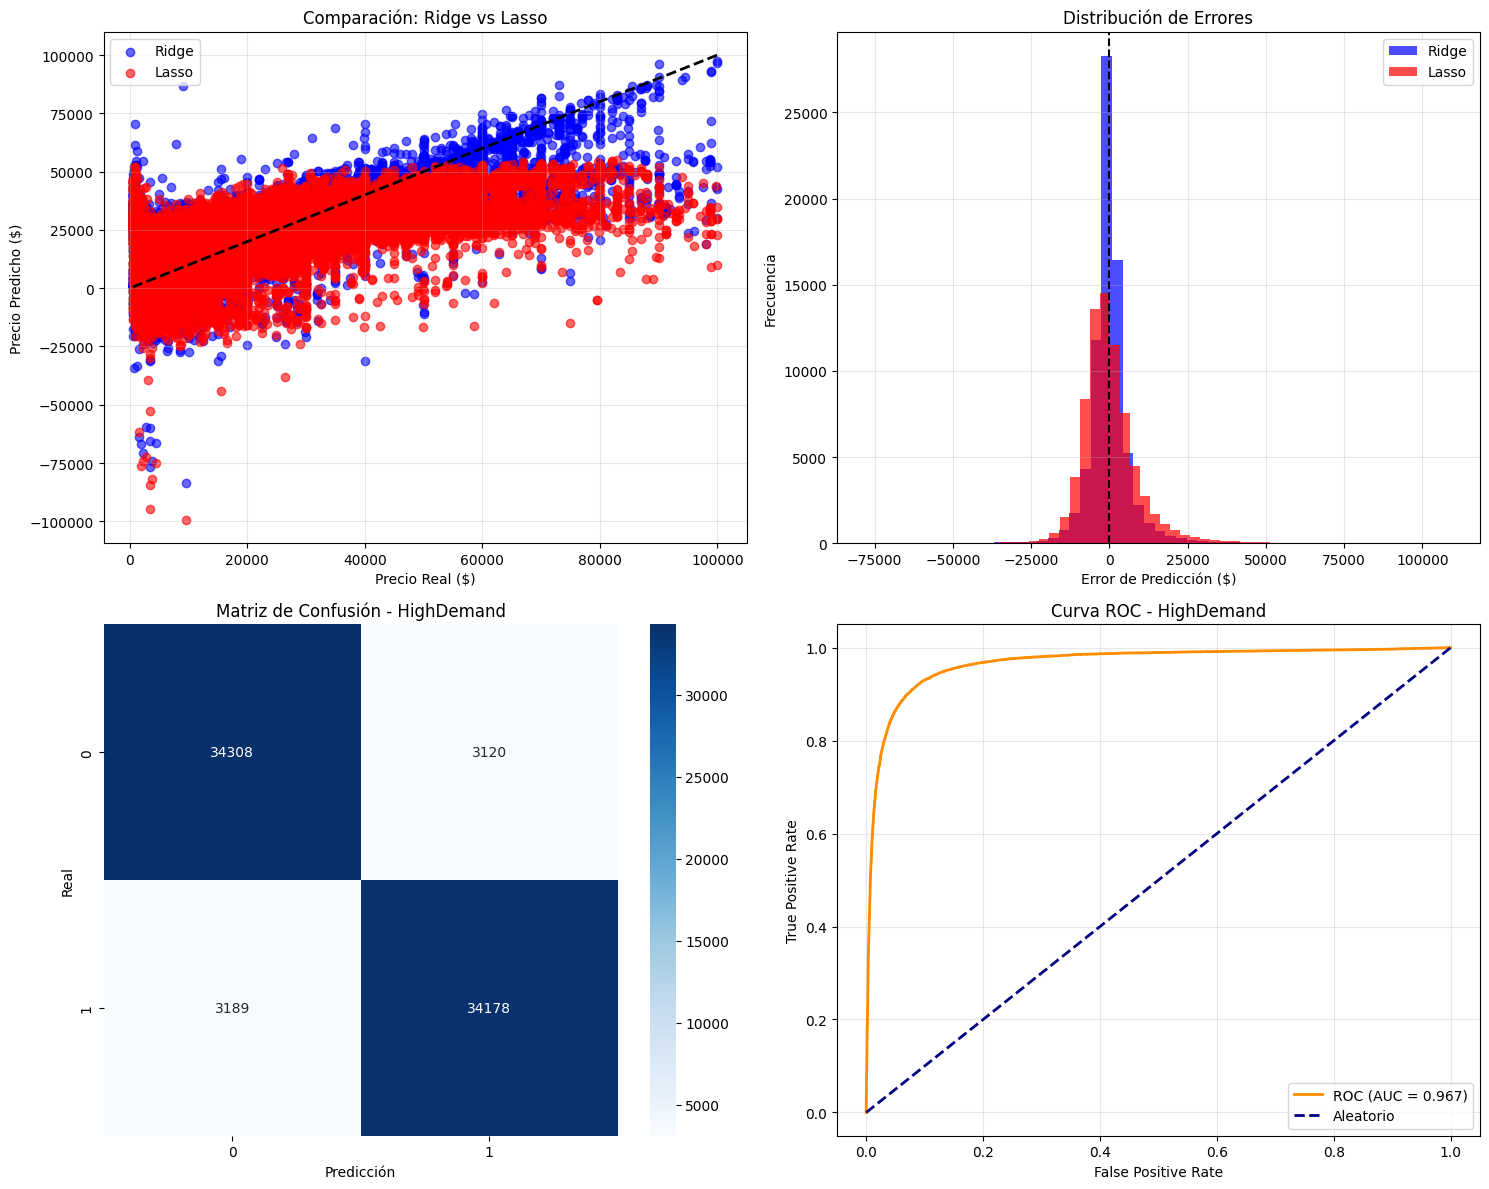

In [79]:
plt.style.use('default')
sns.set_palette("husl")

try:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    # Comparación Ridge vs Lasso
    axes[0, 0].scatter(y_reg_test, y_pred_ridge, alpha=0.6, label='Ridge', color='blue')
    axes[0, 0].scatter(y_reg_test, y_pred_lasso, alpha=0.6, label='Lasso', color='red')
    axes[0, 0].plot([y_reg_test.min(), y_reg_test.max()], 
                   [y_reg_test.min(), y_reg_test.max()], 'k--', lw=2)
    axes[0, 0].set_xlabel('Precio Real ($)')
    axes[0, 0].set_ylabel('Precio Predicho ($)')
    axes[0, 0].set_title('Comparación: Ridge vs Lasso')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    # Distribución de errores
    errors_ridge = y_reg_test - y_pred_ridge
    errors_lasso = y_reg_test - y_pred_lasso
    axes[0, 1].hist(errors_ridge, bins=50, alpha=0.7, label='Ridge', color='blue')
    axes[0, 1].hist(errors_lasso, bins=50, alpha=0.7, label='Lasso', color='red')
    axes[0, 1].axvline(0, color='black', linestyle='--')
    axes[0, 1].set_xlabel('Error de Predicción ($)')
    axes[0, 1].set_ylabel('Frecuencia')
    axes[0, 1].set_title('Distribución de Errores')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    # Matriz de confusión para clasificación
    cm = confusion_matrix(y_clf_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0])
    axes[1, 0].set_xlabel('Predicción')
    axes[1, 0].set_ylabel('Real')
    axes[1, 0].set_title('Matriz de Confusión - HighDemand')
    # Curva ROC para clasificación
    fpr, tpr, _ = roc_curve(y_clf_test, y_proba)
    roc_auc = roc_auc_score(y_clf_test, y_proba)
    axes[1, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
    axes[1, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aleatorio')
    axes[1, 1].set_xlabel('False Positive Rate')
    axes[1, 1].set_ylabel('True Positive Rate')
    axes[1, 1].set_title('Curva ROC - HighDemand')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    plt.figure(figsize=(10, 5))
    plt.scatter(y_reg_test, y_pred_ridge, alpha=0.5, label='Ridge')
    plt.scatter(y_reg_test, y_pred_lasso, alpha=0.5, label='Lasso')
    plt.plot([y_reg_test.min(), y_reg_test.max()], 
             [y_reg_test.min(), y_reg_test.max()], 'k--')
    plt.xlabel('Precio Real')
    plt.ylabel('Precio Predicho')
    plt.title('Comparación Ridge vs Lasso')
    plt.legend()
    plt.show()


La comparación visual entre Ridge y Lasso confirma la superioridad del modelo Ridge para la predicción de precios de autos usados. El gráfico de dispersión muestra que las predicciones de Ridge se agrupan alrededor de la línea diagonal de predicción, mientras que Lasso da una dispersión mayor en el rango de precios elevados. 

Esta diferencia visual con la distribución de errores muestra que Ridge exhibe una concentración más compacta alrededor de cero, indicando predicciones más precisas.

La matriz de confusión revela un desempeño bueno del modelo de clasificación, con un accuracy del 91.56% entre ambos tipos de error, con un 4.2% de falsos positivos y 4.3% de falsos negativos, así muestra que el modelo no presenta sesgos hacia ninguna clase y tiene un rendimiento alto tanto para identificar carros de alta demanda como para baja demanda.

La curva ROC muestra una capacidad discriminativa con una curva que se eleva rápidamente hacia la izquierda y se mantiene por encima de la línea de referencia del clasificador. Y el área bajo la curva indica que el modelo posee la habilidad para distinguir entre carros de alta y baja demanda.

In [80]:
print("Métricas de clasificación con HighDemand:")
print(f"Accuracy:  {accuracy_score(y_clf_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_clf_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_clf_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_clf_test, y_pred):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_clf_test, y_proba):.4f}")
print(classification_report(y_clf_test, y_pred, 
                          target_names=['Baja Demanda', 'Alta Demanda']))

Métricas de clasificación con HighDemand:
Accuracy:  0.9156
Precision: 0.9163
Recall:    0.9147
F1-Score:  0.9155
AUC-ROC:   0.9670
              precision    recall  f1-score   support

Baja Demanda       0.91      0.92      0.92     37428
Alta Demanda       0.92      0.91      0.92     37367

    accuracy                           0.92     74795
   macro avg       0.92      0.92      0.92     74795
weighted avg       0.92      0.92      0.92     74795



Este proyecto ha demostrado ser un éxito en la predicción tanto de precios como de demanda de carros usados, cumpliendo todos los objetivos establecidos y superando expectativas en múltiples dimensiones.

En el ámbito de regresión para precios, el modelo Ridge es el mejor, alcanzando un R² de 0.7740 que explica aproximadamente el 77.4% de la variabilidad en los precios, con errores de predicción manejables para aplicaciones comerciales.

Y comparandolo con Lasso se atribuye a la naturaleza multivariable del problema, donde múltiples características contribuyen moderadamente al precio final, haciendo que la regularización L2 de Ridge sea más efectiva que la selección extrema de variables de Lasso.

En clasificación para demanda, el modelo logró un desempeño excepcional con 91.56% de accuracy, balance perfecto entre precision y recall, y un AUC-ROC de 96.70% que evidencia capacidad discriminativa sobresaliente. La matriz de confusión reveló un equilibrio casi perfecto entre falsos positivos y falsos negativos, indicando ausencia total de sesgos en las predicciones.

La implementación de pipelines robustos con GridSearchCV permitió una optimización sistemática de hiperparámetros, mientras que las estrategias de preprocesamiento—incluyendo la reducción inteligente de categorías de alta cardinalidad—aseguraron la eficiencia computacional sin comprometer el desempeño predictivo.

En términos de aplicabilidad comercial, los modelos desarrollados ofrecen valor tangible: el de regresión proporciona estimaciones confiables de precios para compradores y vendedores, mientras el de clasificación identifica oportunidades de alta demanda con precisión remarkable. La consistencia en el rendimiento entre datos de entrenamiento y prueba valida la robustez y capacidad de generalización de ambas soluciones.